<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/3layer_nn_pytorch_builtin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [3]:
class DeepNN(nn.Module):
    def __init__(self, input_size):
        super(DeepNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.out(x)
        return x

In [4]:
model = DeepNN(X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 1000

losses = []
for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    losses.append(loss.item())

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch [10/1000], Loss: 4.9727
Epoch [20/1000], Loss: 3.5813
Epoch [30/1000], Loss: 1.8164
Epoch [40/1000], Loss: 1.2461
Epoch [50/1000], Loss: 0.8746
Epoch [60/1000], Loss: 0.7514
Epoch [70/1000], Loss: 0.6835
Epoch [80/1000], Loss: 0.6347
Epoch [90/1000], Loss: 0.5946
Epoch [100/1000], Loss: 0.5577
Epoch [110/1000], Loss: 0.5237
Epoch [120/1000], Loss: 0.4937
Epoch [130/1000], Loss: 0.4679
Epoch [140/1000], Loss: 0.4466
Epoch [150/1000], Loss: 0.4295
Epoch [160/1000], Loss: 0.4159
Epoch [170/1000], Loss: 0.4048
Epoch [180/1000], Loss: 0.3955
Epoch [190/1000], Loss: 0.3877
Epoch [200/1000], Loss: 0.3813
Epoch [210/1000], Loss: 0.3756
Epoch [220/1000], Loss: 0.3705
Epoch [230/1000], Loss: 0.3657
Epoch [240/1000], Loss: 0.3612
Epoch [250/1000], Loss: 0.3569
Epoch [260/1000], Loss: 0.3528
Epoch [270/1000], Loss: 0.3488
Epoch [280/1000], Loss: 0.3449
Epoch [290/1000], Loss: 0.3409
Epoch [300/1000], Loss: 0.3368
Epoch [310/1000], Loss: 0.3327
Epoch [320/1000], Loss: 0.3286
Epoch [330/1000],

In [6]:
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)

print("Test MSE:", test_loss.item())

Test MSE: 0.281177818775177


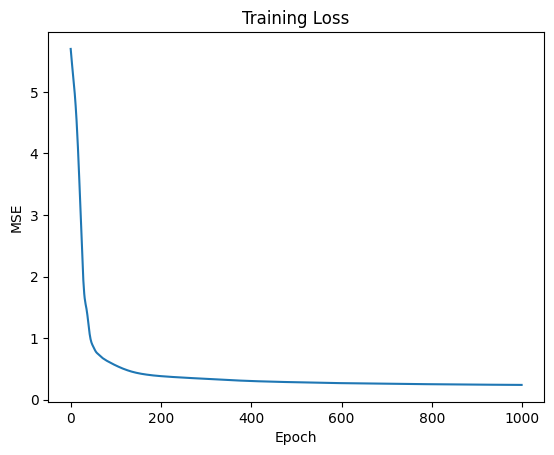

In [7]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()